# Cycle 3 — Modelling: Player Injury Risk

**Project:** Football Predictor  
**Depends on:** `cycle3_preprocessing_injuries.ipynb`  
**Dataset:** `data/processed/player_injuries_processed.csv`

---

## Purpose

Train and evaluate baseline models for player injury risk prediction. The target is `High_Injury` (1 = player misses 28+ days this season, 0 = misses fewer than 28 days). This is a binary classification problem with a 70/30 class imbalance.

## Why AUC-ROC?

A dummy classifier that always predicts High Injury achieves 70.1% accuracy. AUC-ROC measures real discriminative ability regardless of threshold. An AUC of 0.5 = random, 1.0 = perfect.

## Injury Prediction is Hard

Injury prediction is widely acknowledged as one of the most difficult problems in sports analytics. Published models in sports science literature typically achieve AUC between 0.60 and 0.70. The fundamental challenge is that many causal injury factors (training load, pitch conditions, mental fatigue, specific tackle events) are not captured in the features available to us. The dataset provides physical attributes and historical injury data — useful, but incomplete.

In [5]:
import sys, os

# Locate project root (folder containing data/, models/, notebooks/)
_here = os.getcwd()
while not os.path.isdir(os.path.join(_here, 'data')):
    _p = os.path.dirname(_here)
    if _p == _here: raise RuntimeError('project root not found')
    _here = _p
if _here not in sys.path:
    sys.path.insert(0, _here)

from config import Paths, ensure_dirs
ensure_dirs()  # creates models/cycle1-3 if missing


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, roc_curve
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

df = pd.read_csv(str(Paths.PLAYER_INJURIES_PROCESSED))
X = df.drop(columns=['High_Injury'])
y = df['High_Injury']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

spw = y_train.value_counts()[0] / y_train.value_counts()[1]

print(f'Train: {len(X_train)} | Test: {len(X_test)}')
print(f'High Injury rate - Train: {y_train.mean()*100:.1f}% | Test: {y_test.mean()*100:.1f}%')
print(f'scale_pos_weight: {spw:.2f}')
print(f'Features ({len(X.columns)}): {list(X.columns)}')

Train: 1040 | Test: 261
High Injury rate - Train: 70.2% | Test: 70.1%
scale_pos_weight: 0.42
Features (17): ['height_cm', 'weight_kg', 'pace', 'physic', 'fifa_rating', 'age', 'cumulative_minutes_played', 'cumulative_games_played', 'minutes_per_game_prev_seasons', 'avg_days_injured_prev_seasons', 'avg_games_per_season_prev_seasons', 'bmi', 'work_rate_numeric', 'position_numeric', 'significant_injury_prev_season', 'cumulative_days_injured', 'season_days_injured_prev_season']


### Observations
- Note: scale_pos_weight = 0.42 (less than 1.0) because the majority class is High Injury (70.2%), not Low Injury. XGBoost needs to upweight the minority class (Low Injury, 29.8%)
- The dataset is small: only 1,040 training rows. This limits complex model performance and explains why tuning gains will be modest

## Dummy Classifier

In [7]:
dummy = DummyClassifier(strategy='most_frequent', random_state=42)
dummy.fit(X_train_s, y_train)
y_pred_d = dummy.predict(X_test_s)
y_prob_d = dummy.predict_proba(X_test_s)[:,1]

print('DUMMY CLASSIFIER')
print(f'  Accuracy: {accuracy_score(y_test, y_pred_d)*100:.2f}%  |  AUC: {roc_auc_score(y_test, y_prob_d):.4f}')
print(classification_report(y_test, y_pred_d, target_names=['Low Injury','High Injury']))

DUMMY CLASSIFIER
  Accuracy: 70.11%  |  AUC: 0.5000
              precision    recall  f1-score   support

  Low Injury       0.00      0.00      0.00        78
 High Injury       0.70      1.00      0.82       183

    accuracy                           0.70       261
   macro avg       0.35      0.50      0.41       261
weighted avg       0.49      0.70      0.58       261



### Observations
- 70.11% accuracy from always predicting High Injury -- confirms why accuracy is misleading
- AUC 0.5 = random guessing. All real models must exceed this

## Logistic Regression

In [8]:
lr = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
lr.fit(X_train_s, y_train)
y_pred_lr = lr.predict(X_test_s)
y_prob_lr = lr.predict_proba(X_test_s)[:,1]

print('LOGISTIC REGRESSION')
print(f'  Accuracy: {accuracy_score(y_test, y_pred_lr)*100:.2f}%  |  AUC: {roc_auc_score(y_test, y_prob_lr):.4f}')
print(classification_report(y_test, y_pred_lr, target_names=['Low Injury','High Injury']))

LOGISTIC REGRESSION
  Accuracy: 55.17%  |  AUC: 0.6220
              precision    recall  f1-score   support

  Low Injury       0.36      0.62      0.45        78
 High Injury       0.76      0.52      0.62       183

    accuracy                           0.55       261
   macro avg       0.56      0.57      0.54       261
weighted avg       0.64      0.55      0.57       261



### Observations
- AUC 0.6220: best baseline model despite lowest accuracy (55.17%)
- Balanced weighting causes more Low Injury predictions, trading accuracy for better discrimination
- Low Injury recall 0.62 -- correctly identifies 62% of low-risk players
- Consistent with sports science literature: linear models perform well when injury risk has an approximately linear relationship with history metrics

## Random Forest

In [9]:
rf = RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42, n_jobs=-1)
rf.fit(X_train_s, y_train)
y_pred_rf = rf.predict(X_test_s)
y_prob_rf = rf.predict_proba(X_test_s)[:,1]

print('RANDOM FOREST')
print(f'  Accuracy: {accuracy_score(y_test, y_pred_rf)*100:.2f}%  |  AUC: {roc_auc_score(y_test, y_prob_rf):.4f}')
print(classification_report(y_test, y_pred_rf, target_names=['Low Injury','High Injury']))

RANDOM FOREST
  Accuracy: 72.03%  |  AUC: 0.5916
              precision    recall  f1-score   support

  Low Injury       0.65      0.14      0.23        78
 High Injury       0.73      0.97      0.83       183

    accuracy                           0.72       261
   macro avg       0.69      0.55      0.53       261
weighted avg       0.70      0.72      0.65       261



### Observations
- High accuracy (72.03%) but AUC only 0.5916 which is near-random discrimination
- Model is essentially predicting High Injury for almost everyone (recall 0.97)
- This shows Random Forest with default settings collapses to majority-class prediction despite balanced weighting

## XGBoost

In [10]:
xgb = XGBClassifier(scale_pos_weight=spw, random_state=42, eval_metric='auc', verbosity=0)
xgb.fit(X_train_s, y_train)
y_pred_xgb = xgb.predict(X_test_s)
y_prob_xgb = xgb.predict_proba(X_test_s)[:,1]

print('XGBOOST')
print(f'  Accuracy: {accuracy_score(y_test, y_pred_xgb)*100:.2f}%  |  AUC: {roc_auc_score(y_test, y_prob_xgb):.4f}')
print(classification_report(y_test, y_pred_xgb, target_names=['Low Injury','High Injury']))

XGBOOST
  Accuracy: 65.52%  |  AUC: 0.6179
              precision    recall  f1-score   support

  Low Injury       0.41      0.36      0.38        78
 High Injury       0.74      0.78      0.76       183

    accuracy                           0.66       261
   macro avg       0.58      0.57      0.57       261
weighted avg       0.64      0.66      0.65       261



### Observations
- AUC 0.6179: competitive with LR. scale_pos_weight correctly pushes XGBoost to predict Low Injury more
- Better than RF at discrimination (0.6179 vs 0.5916) but worse than LR (0.6220)

## LightGBM

In [11]:
lgb = LGBMClassifier(scale_pos_weight=spw, n_estimators=100, random_state=42, verbose=-1)
lgb.fit(X_train_s, y_train)
y_pred_lgb = lgb.predict(X_test_s)
y_prob_lgb = lgb.predict_proba(X_test_s)[:,1]

print('LIGHTGBM')
print(f'  Accuracy: {accuracy_score(y_test, y_pred_lgb)*100:.2f}%  |  AUC: {roc_auc_score(y_test, y_prob_lgb):.4f}')
print(classification_report(y_test, y_pred_lgb, target_names=['Low Injury','High Injury']))

LIGHTGBM
  Accuracy: 67.43%  |  AUC: 0.6355
              precision    recall  f1-score   support

  Low Injury       0.45      0.37      0.41        78
 High Injury       0.75      0.80      0.78       183

    accuracy                           0.67       261
   macro avg       0.60      0.59      0.59       261
weighted avg       0.66      0.67      0.67       261



# ROC Curve Comparison

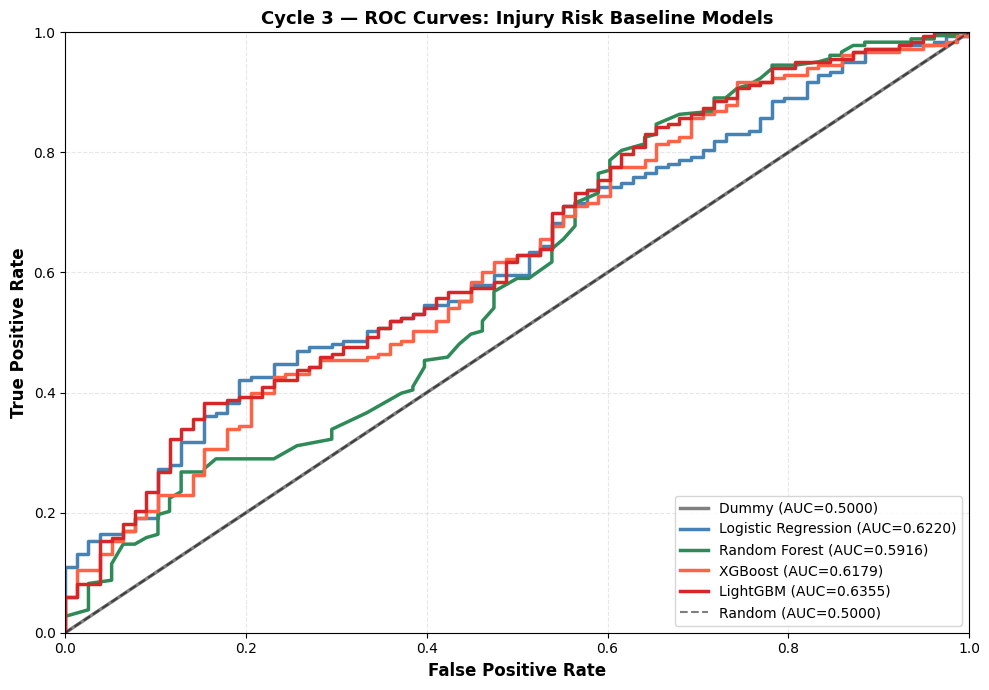

In [12]:
os.makedirs('../../docs', exist_ok=True)

fig, ax = plt.subplots(figsize=(10, 7))
for name, probs, color in [
    ('Dummy',               y_prob_d,   'gray'),
    ('Logistic Regression', y_prob_lr,  'steelblue'),
    ('Random Forest',       y_prob_rf,  'seagreen'),
    ('XGBoost',             y_prob_xgb, 'tomato'),
    ('LightGBM',            y_prob_lgb, '#d62728'),
]:
    fpr, tpr, _ = roc_curve(y_test, probs)
    auc = roc_auc_score(y_test, probs)
    ax.plot(fpr, tpr, label=f'{name} (AUC={auc:.4f})', color=color, linewidth=2.5)

ax.plot([0,1],[0,1],'k--',linewidth=1.5, alpha=0.5, label='Random (AUC=0.5000)')
ax.set_xlabel('False Positive Rate', fontsize=12, fontweight='bold')
ax.set_ylabel('True Positive Rate', fontsize=12, fontweight='bold')
ax.set_title('Cycle 3 — ROC Curves: Injury Risk Baseline Models', fontsize=13, fontweight='bold')
ax.legend(loc='lower right', fontsize=10)
ax.grid(alpha=0.3, linestyle='--')
ax.set_xlim([0, 1])
ax.set_ylim([0, 1])
plt.tight_layout()
plt.savefig('../../docs/cycle3_roc_baseline.png', dpi=300, bbox_inches='tight')
plt.show()

# Full Baseline Summary

In [15]:
results = pd.DataFrame([
    {'Model': 'Dummy',               'Accuracy': accuracy_score(y_test, y_pred_d)*100, 'AUC-ROC': roc_auc_score(y_test, y_prob_d)},
    {'Model': 'Logistic Regression', 'Accuracy': accuracy_score(y_test, y_pred_lr)*100, 'AUC-ROC': roc_auc_score(y_test, y_prob_lr)},
    {'Model': 'Random Forest',       'Accuracy': accuracy_score(y_test, y_pred_rf)*100, 'AUC-ROC': roc_auc_score(y_test, y_prob_rf)},
    {'Model': 'XGBoost',             'Accuracy': accuracy_score(y_test, y_pred_xgb)*100, 'AUC-ROC': roc_auc_score(y_test, y_prob_xgb)},
    {'Model': 'LightGBM',            'Accuracy': accuracy_score(y_test, y_pred_lgb)*100, 'AUC-ROC': roc_auc_score(y_test, y_prob_lgb)},
])

results['Accuracy'] = results['Accuracy'].round(2)
results['AUC-ROC'] = results['AUC-ROC'].round(4)
print(results.sort_values('AUC-ROC', ascending=False).to_string(index=False))
print()
best = results.loc[results['AUC-ROC'].idxmax()]
print(f'Best baseline: {best["Model"]} (AUC={best["AUC-ROC"]})')

              Model  Accuracy  AUC-ROC
           LightGBM     67.43   0.6355
Logistic Regression     55.17   0.6220
            XGBoost     65.52   0.6179
      Random Forest     72.03   0.5916
              Dummy     70.11   0.5000

Best baseline: LightGBM (AUC=0.6355)
